In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

# %cd /content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms/

In [24]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.compose import ColumnTransformer 
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import eda_util

In [2]:
RANDOM_STATE = 1048576
TARGET = 'accident_risk'

# Data Loading

In [3]:
train_csv = pd.read_csv('datasets/train_split.csv', index_col=0)
val_csv = pd.read_csv('datasets/val_split.csv', index_col=0)
test_csv = pd.read_csv('datasets/test_split.csv', index_col=0)

In [4]:
display(train_csv.head())
display(val_csv.head())
display(test_csv.head())

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
313352,rural,2,0.22,45,night,foggy,False,True,evening,True,False,2,0.36
348526,rural,4,0.22,35,night,foggy,True,False,afternoon,True,False,2,0.42
419885,urban,1,0.18,60,dim,rainy,True,False,evening,False,False,0,0.40
37241,rural,2,0.92,25,dim,clear,True,True,afternoon,False,True,1,0.35
85356,urban,4,0.14,25,night,rainy,True,True,evening,True,False,0,0.34


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
262368,rural,4,0.37,35,daylight,clear,True,False,evening,False,False,1,0.06
341957,rural,4,0.75,60,daylight,clear,False,False,morning,True,True,2,0.48
66336,rural,2,0.66,35,daylight,foggy,True,True,morning,False,True,1,0.32
325259,highway,2,0.90,45,night,clear,True,True,evening,True,True,0,0.45
477777,rural,2,0.28,25,night,rainy,True,True,evening,False,False,2,0.46


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
73059,highway,4,0.49,70,dim,rainy,False,True,afternoon,False,True,0,0.49
292825,urban,3,0.56,45,dim,foggy,True,True,evening,True,True,1,0.21
282017,highway,1,0.90,25,daylight,clear,False,False,morning,False,True,0,0.23
69101,rural,2,0.58,70,night,clear,False,True,afternoon,True,False,1,0.52
505439,rural,4,0.54,45,daylight,foggy,True,False,afternoon,True,True,2,0.24


In [5]:
print(f'Training set shape: {train_csv.shape}, Validation set shape: {val_csv.shape}, Test set shape: {test_csv.shape}')
eda_util.DataImport.datasplit_info(train_csv, val_csv, test_csv)

Training set shape: (414203, 13), Validation set shape: (51775, 13), Test set shape: (51776, 13)


,Column,Train Null Count,Val Null Count,Test Null Count,Dtype
0,road_type,0,0,0,object
1,num_lanes,0,0,0,int64
2,curvature,0,0,0,float64
3,speed_limit,0,0,0,int64
4,lighting,0,0,0,object
5,weather,0,0,0,object
6,road_signs_present,0,0,0,bool
7,public_road,0,0,0,bool
8,time_of_day,0,0,0,object
9,holiday,0,0,0,bool


# Feature-Target Split

In [6]:
X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_val, y_val = val_csv.drop(columns=[TARGET]), val_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}')

X_train shape: (414203, 12), X_val shape: (51775, 12), X_test shape: (51776, 12)


# Preprocessing

In [7]:
cat_features = ['road_type', 'lighting', 'weather', 'time_of_day']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = X_train.columns.difference(cat_features + bool_features).tolist()

## Change 'unknown' to np.nan

In [8]:
# class CustomImputer(BaseEstimator, TransformerMixin):
#     def __init__(self, na: str | list=None):
#         self.na = na if type(na) is list else [na] if na else []
#         return

#     def fit(self, X, y=None):
#         self.columns = X.columns
#         return self
    
#     def transform(self, X, y=None):
#         X = X.copy()
#         for feature in self.columns:
#             for na in self.na:
#                 X[feature] = X[feature].replace(na, np.nan)
#         return X
    

In [9]:
# X_train_imputed = CustomImputer(na=['unknown']).fit_transform(X_train)
# cat_features_info = pd.DataFrame(X_train_imputed[cat_features].nunique(), columns=['Number of Unique Classes']).reset_index(names='Features')
# cat_features_info['Unique Classes'] = cat_features_info['Features'].apply(lambda x: X_train_imputed[x].unique()) # Number of unique classes in categorical features
# cat_features_info

## Categorical Encoding

In [10]:
ord_features = ['lighting', 'time_of_day']
nom_features = ['road_type', 'weather']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

In [16]:
encoders = ColumnTransformer([
    ('nom_features', OrdinalEncoder(dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan), nom_features),
    ('ord_features', OrdinalEncoder(dtype=float, categories=[
        ['night', 'dim', 'daylight'], 
        ['morning', 'afternoon', 'evening']
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), ord_features),
    ('bool_features', OrdinalEncoder(dtype=float, categories=[
        [False, True] for i in range(len(bool_features))
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), bool_features)
], 
remainder='passthrough',
verbose_feature_names_out=False)
encoders

,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'float'>
,handle_unknown,'use_encoded_value'


In [17]:
encoders.set_output(transform='pandas')
encoders.fit_transform(X_train).head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents
id,,,,,,,,,,,,
313352,1.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,2,0.22,45,2
348526,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4,0.22,35,2
419885,2.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1,0.18,60,0
37241,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,2,0.92,25,1
85356,2.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0,4,0.14,25,0


## Time features

In [18]:
# def add_time_features(X):
#     X = X.copy()
#     X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
#     X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
#     X["day_sin"] = np.sin(2 * np.pi * X["day"] / 31)
#     X["day_cos"] = np.cos(2 * np.pi * X["day"] / 31)
#     return X

# time_transformer = FunctionTransformer(add_time_features)
# time_transformer

## Feature Engineering

In [59]:
def add_related_features(X):
    X = X.copy()
    X['curvature_speed_limit'] = X['curvature'] * X['speed_limit']
    X['curvature_speed_limit_2'] = X['speed_limit'] ** 2 * X['curvature']
    return X

add_transformer = FunctionTransformer(add_related_features)
add_transformer

,func,<function add...0024B2DBD3920>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


## Full preprocessing pipeline

In [60]:
full_preprocessor = Pipeline(steps=[
    ('encoder', encoders),
    ('add_rel_feature', add_transformer)
])
full_preprocessor

,steps,"[('encoder', ...), ('add_rel_feature', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## Label Encoding

In [61]:
# l_encoder = LabelEncoder()
# l_encoder.fit(y_train)
# y_train_encoded = l_encoder.transform(y_train)
# y_val_encoded = l_encoder.transform(y_val)
# y_test_encoded = l_encoder.transform(y_test)
# print(f'Encoded y_train shape: {y_train_encoded.shape}, Encoded y_val shape: {y_val_encoded.shape}, Encoded y_test shape: {y_test_encoded.shape}')

# Model Building

## Base Model

In [62]:
X_train_encoded = full_preprocessor.fit_transform(X_train)
X_val_encoded = full_preprocessor.transform(X_val)
X_test_encoded = full_preprocessor.transform(X_test)
display(X_train_encoded.head())
display(X_val_encoded.head())
display(X_test_encoded.head())

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
313352,1.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,2,0.22,45,2,9.9,445.5
348526,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4,0.22,35,2,7.7,269.5
419885,2.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1,0.18,60,0,10.8,648.0
37241,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,2,0.92,25,1,23.0,575.0
85356,2.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0,4,0.14,25,0,3.5,87.5


,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
262368,1.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,4,0.37,35,1,12.95,453.25
341957,1.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,4,0.75,60,2,45.00,2700.00
66336,1.0,1.0,2.0,0.0,1.0,1.0,0.0,1.0,2,0.66,35,1,23.10,808.50
325259,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,2,0.90,45,0,40.50,1822.50
477777,1.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,2,0.28,25,2,7.00,175.00


,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
73059,0.0,2.0,1.0,1.0,0.0,1.0,0.0,1.0,4,0.49,70,0,34.3,2401.0
292825,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,3,0.56,45,1,25.2,1134.0
282017,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1,0.90,25,0,22.5,562.5
69101,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,2,0.58,70,1,40.6,2842.0
505439,1.0,1.0,2.0,1.0,1.0,0.0,1.0,1.0,4,0.54,45,2,24.3,1093.5


In [63]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 414203 entries, 313352 to 399966
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   road_type                414203 non-null  float64
 1   weather                  414203 non-null  float64
 2   lighting                 414203 non-null  float64
 3   time_of_day              414203 non-null  float64
 4   road_signs_present       414203 non-null  float64
 5   public_road              414203 non-null  float64
 6   holiday                  414203 non-null  float64
 7   school_season            414203 non-null  float64
 8   num_lanes                414203 non-null  int64  
 9   curvature                414203 non-null  float64
 10  speed_limit              414203 non-null  int64  
 11  num_reported_accidents   414203 non-null  int64  
 12  curvature_speed_limit    414203 non-null  float64
 13  curvature_speed_limit_2  414203 non-null  float64
dtypes: f

In [64]:
base_model = LGBMRegressor(random_state=RANDOM_STATE)
base_model.fit(X_train_encoded, y_train, eval_set=(X_val_encoded, y_val), eval_metric='rmse', categorical_feature=cat_features + bool_features, feature_name=X_train_encoded.columns.to_list())
print(f'Training Score: {rmse(y_train, base_model.predict(X_train_encoded))}')
print(f'Validation Score: {rmse(y_val, base_model.predict(X_val_encoded))}')
print(f'Test Score: {rmse(y_test, base_model.predict(X_test_encoded))}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 14
[LightGBM] [Info] Start training from score 0.352416
Training Score: 0.05607814765064544
Validation Score: 0.0562706407916525
Test Score: 0.05666818315221502


In [65]:
base_model.best_score_

defaultdict(collections.OrderedDict,
            {'valid_0': OrderedDict([('rmse',
                           np.float64(0.056270640462013764)),
                          ('l2', np.float64(0.0031663849780052206))])})

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

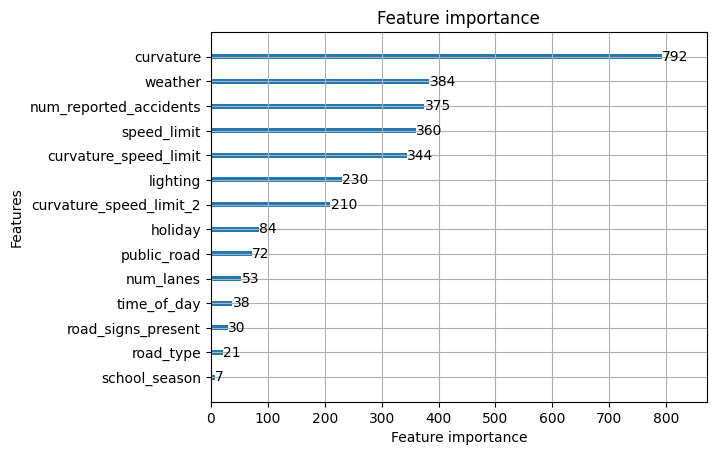

In [66]:
lgb.plot_importance(base_model)

## Bayes Search with 10-fold CV

In [71]:
kf = KFold(n_splits = 10, shuffle = True, random_state = RANDOM_STATE)        # Construct a 10-fold shuffler
reg = lgb.LGBMRegressor(random_state=RANDOM_STATE)                            # Base estimator
opt = BayesSearchCV(reg,                                                      # Param Space
                    {
                        "max_depth": Integer(3, 13),
                        "num_leaves": Integer(20, 200),
                        "min_child_samples": Integer(7, 75),
                        "colsample_bytree": Real(0.25, 1),
                        "subsample": Real(0.25, 1),
                        "subsample_freq": Integer(1, 50),
                        "reg_alpha": Real(0, 1),
                        "reg_lambda": Real(0, 1),
                        "min_split_gain": Real(0, 0.5)
                    },
                    n_iter = 150,
                    cv = kf,
                    n_jobs = 3,
                    random_state = RANDOM_STATE,
                    fit_params={"eval_metric": 'rmse',
                                "categorical_feature": cat_features + bool_features, 
                                'feature_name': X_train_encoded.columns.to_list()},         # Passing categorical features to LGBMClassifier
                    verbose=2
                   )
opt

,estimator,LGBMRegressor...state=1048576)
,search_spaces,"{'colsample_bytree': Real(low=0.25...rm='identity'), 'max_depth': Integer(low=3...rm='identity'), 'min_child_samples': Integer(low=7...rm='identity'), 'min_split_gain': Real(low=0, h...rm='identity'), ...}"
,optimizer_kwargs,None
,n_iter,150
,scoring,None
,fit_params,"{'categorical_feature': ['road_type', 'lighting', ...], 'eval_metric': 'rmse', 'feature_name': ['road_type', 'weather', ...]}"
,n_jobs,3
,n_points,1
,iid,'deprecated'
,refit,True
,cv,KFold(n_split... shuffle=True)


In [72]:
from joblib import parallel_backend

with parallel_backend('threading'):
    opt.fit(X_train_encoded, y_train)

display(opt.best_estimator_)

print(f'Best parameters are {opt.best_params_}')
print(f'Best score is {opt.best_score_}')

Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   2.1s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   2.5s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769515544431, reg_lambda=0.624274461459859, subsample=0.5656782387409611, subsample_freq=31; total time=   2.7s
[CV] END colsample_bytree=0.47669661480464925, max_depth=6, min_child_samples=58, min_split_gain=0.16288111478910497, num_leaves=102, reg_alpha=0.5554769

,boosting_type,'gbdt'
,num_leaves,200
,max_depth,10
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,7


Best parameters are OrderedDict({'colsample_bytree': 0.8493572881686531, 'max_depth': 10, 'min_child_samples': 7, 'min_split_gain': 0.0, 'num_leaves': 200, 'reg_alpha': 0.47425633418045277, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_freq': 50})
Best score is 0.8867194604072808


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

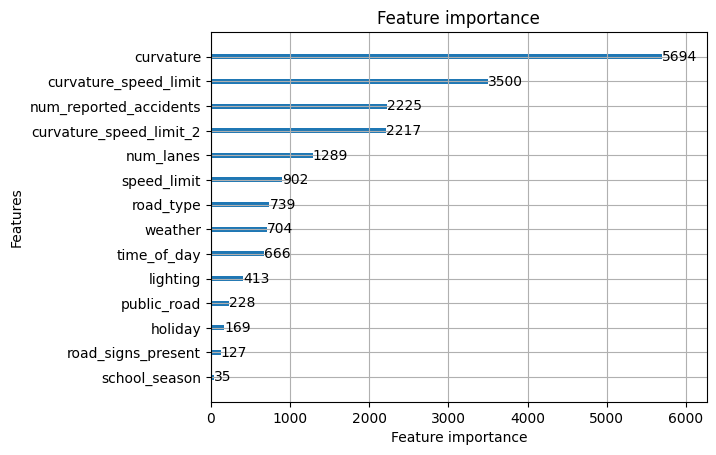

In [73]:
lgb.plot_importance(opt.best_estimator_)

In [74]:
param_dict = opt.best_params_


In [75]:
import joblib

best_lgb = opt.best_estimator_
joblib.dump(best_lgb, 'best_lgb_model.pkl')


# best_lgb = joblib.load('best_lgb_model.pkl')
# best_lgb.fit(X_train_encoded, y_train_dropped)
# best_lgb

['best_lgb_model.pkl']

In [76]:
print(f'Test Score: {rmse(y_test, best_lgb.predict(X_test_encoded))}')

Test Score: 0.056352111261889284


# Submit Prediction

In [77]:
full_test_csv = pd.read_csv('datasets/test.csv', index_col=0)
full_test_encoded = full_preprocessor.transform(full_test_csv)
full_test_encoded.head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
517754,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,2,0.34,45,1,15.30,688.50
517755,2.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,3,0.04,45,0,1.80,81.00
517756,2.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2,0.59,35,1,20.65,722.75
517757,1.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,4,0.95,35,2,33.25,1163.75
517758,0.0,0.0,2.0,2.0,1.0,0.0,0.0,1.0,2,0.86,35,3,30.10,1053.50


## Base Model

In [69]:
y_pred = base_model.predict(full_test_encoded)

In [70]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_LGBM_base.csv')
print('Result saved successfully!')

        accident_risk
id                   
517754          0.352
517755          0.352
517756          0.352
517757          0.352
517758          0.352


        accident_risk
id                   
517754       0.289695
517755       0.125532
517756       0.176336
517757       0.319318
517758       0.391948
Result saved successfully!


## Best LGB Classifier

In [78]:
y_pred = best_lgb.predict(full_test_encoded)

In [79]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred.round(3)
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_LGBM_Bayes.csv')
print('Result saved successfully!')

        accident_risk
id                   
517754          0.352
517755          0.352
517756          0.352
517757          0.352
517758          0.352


        accident_risk
id                   
517754          0.292
517755          0.121
517756          0.176
517757          0.311
517758          0.406
Result saved successfully!
